In [1]:
!pip install -r ../requirements.txt

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb

Napomena - pri višestrukom ponavljanju ove analize zaklučio sam da je dataset pun duplikata, jedan od razloga za to je zato što je ovaj dataset prikupljen korišćenjem honeypot mejlova. Ovo je imalo za posledicu da moji modeli imaju preciznost od 99%, tako da sam odlučio da odbacim što više duplikata tako da bi model bio generalizovan i treniran na heterogenim terminima u mejlovima.

In [3]:
data = pd.read_csv('../data/emails/CEAS_08.csv')
# data = data.sample(n=5000,random_state=42)
data = data.drop_duplicates(subset=['subject'], keep='first')
data = data.drop_duplicates(subset=['body'], keep='first')
data = data.drop_duplicates(subset=['sender','receiver'],keep='first')
data

,sender,receiver,date,subject,body,label,urls
0,Young Esposito <Young@iworld.de>,user4@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 16:31:02 -0700",Never agree to be a loser,"Buck up, your troubles caused by small dimensi...",1,1
1,Mok <ipline's1983@icable.ph>,user2.2@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 18:31:03 -0500",Befriend Jenna Jameson,\nUpgrade your sex and pleasures with these te...,1,1
2,Daily Top 10 <Karmandeep-opengevl@universalnet...,user2.9@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 20:28:00 -1200",CNN.com Daily Top 10,>+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+...,1,1
3,Michael Parker <ivqrnai@pobox.com>,SpamAssassin Dev <xrh@spamassassin.apache.org>,"Tue, 05 Aug 2008 17:31:20 -0600",Re: svn commit: r619753 - in /spamassassin/tru...,Would anyone object to removing .so from this ...,0,1
4,Gretchen Suggs <externalsep1@loanofficertool.com>,user2.2@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 19:31:21 -0400",SpecialPricesPharmMoreinfo,\nWelcomeFastShippingCustomerSupport\nhttp://7...,1,1
...,...,...,...,...,...,...,...
39136,bradly weidong <administrator@aba-uk.org>,cstheory@gvc.ceas-challenge.cc,"Fri, 08 Aug 2008 12:11:35 +0000",Finally your new healthy life. 85,\n Find your love stick gain he...,1,0
39138,robert healy <vrcjauctt@gmail.com>,pvosgpr@triptracker.net,"Fri, 08 Aug 2008 05:59:51 -0800",I want to cancel my account,How do I cancel my account. I want to erase i...,0,0
39139,freddie <freddie_jeffries@branch3es.info>,user2.1-ext1@gvc.ceas-challenge.cc,"Fri, 08 Aug 2008 13:59:53 +0000",some contact information for you,This message is intended for :\n\n*SAVE! SAVE...,1,1
39143,Wendy Richter <gerich@miffbank.com>,brenda.semien@gvc.ceas-challenge.cc,"Fri, 08 Aug 2008 15:00:15 +0100",Woman 38 Richter,+++++++++++++++++++++++++++++++++++\nLana\nI a...,1,1


U datom datasetu postoje sledece promenljive:
Sender - Naziv posiljaoca  i mejl adresa
Receiver - mejl adresa primaoca
Date - datum slanja
Subject - naslov mejla
Body - sadrzaj mejla
Label - binarna promenljiva koja oznacava da li mejl predstavlja phishing napad ili ne. 1 je phishing dok 0 nije.
Urls - binarna promenljiva koja oznacava da li se u mejlu nalaze url-ovi

Prvo sto cu da proverim je ucestalost vrednosti promenljivih koje u sebi sadrze NA vrednosti

In [4]:
data.info()

<class 'pandas.DataFrame'>
Index: 11185 entries, 0 to 39151
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   sender    11185 non-null  str  
 1   receiver  11102 non-null  str  
 2   date      11185 non-null  str  
 3   subject   11184 non-null  str  
 4   body      11185 non-null  str  
 5   label     11185 non-null  int64
 6   urls      11185 non-null  int64
dtypes: int64(2), str(5)
memory usage: 699.1 KB


In [5]:
data.receiver.value_counts()

receiver
user6@gvc.ceas-challenge.cc                                               397
user2.2@gvc.ceas-challenge.cc                                             395
user2.4@gvc.ceas-challenge.cc                                             299
user7-ext4@gvc.ceas-challenge.cc                                          292
user2.13@gvc.ceas-challenge.cc                                            291
                                                                         ... 
Christian Campbell <yekxpbaab@brueggers.com>                                1
Rich Neo <bf-jgyyrpxggb@neiu.edu>                                           1
Dave Koontz <fcquqwd@mbc.edu>                                               1
"Maier,Chris" <dmeuc.tpvnl@heb.com>                                         1
rgkwpdahmhmail@cs.cmu.edu, faq@engr.orst.edu, ji-ivay@googlegroups.com      1
Name: count, Length: 1954, dtype: int64

Kao sto se moze videti, veliki broj mejlova ima iste primaoce, pretpostavljam da su ovi mejlovi sluzili kao honeypot-ovi za prikupljanje phishing napada. Podaci primaoca se onda tesko mogu koristiti za klasifikaciju.

Postoji rizik od overfitting-a, ukoliko treniram model na ovim podacima. Jedino za sta bi mogla da mi sluzi promenljiva primaoc je da se na primer poredi adresa primaoca i posiljaoca. Ukoliko su mejl serveri isti, onda postoji veca sansa da je mejl validan

Probacu da nadjem mejlove(opservacije) koje sadrze isti mejl servera posiljaoca i primaoca

In [6]:
sender_domain = data['sender'].str.split("@").str[1].str.removesuffix(">")
receiver_domain = data['receiver'].str.split("@").str[1].str.removesuffix(">")

internal_sending_data = data.loc[sender_domain == receiver_domain]
internal_sending_data

,sender,receiver,date,subject,body,label,urls
22,ohwwlejs-pbfotbp@list.scms.waikato.ac.nz,iuxxdkqk@list.scms.waikato.ac.nz,"Tue, 05 Aug 2008 18:32:19 -0500","Wekalist Digest, Vol 60, Issue 10",Send Wekalist mailing list submissions to\n\ti...,0,1
54,Perl Jobs <xycn-vtnhz@perl.org>,necc@perl.org,"Tue, 05 Aug 2008 02:47:22 -0800","[Perl Jobs] Perl developer, Hungary, Budapest",Online URL for this job: http://jobs.perl.org/...,0,1
88,"""Mickisch, Freda"" <e.bsnrgtrf@massey.ac.nz>",yrvc-tke@massey.ac.nz,"Wed, 06 Aug 2008 12:34:55 +1300",Supervisors PhD students: 6-monthly reports...,Hi \n\n \n\nJust a reminder that these are due...,0,0
102,user2.13@gvc.ceas-challenge.cc,user2.13@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 14:36:16 -0400",Angelina Jolie Free Video.,\n\n\n\n\n\n\n\n\n\n\n\nFree Video Nude Anjeli...,1,0
123,demerphq <oryiufjn@gmail.com>,Rafael Garcia-Suarez <pvhuhqgncrxnu@gmail.com>,"Wed, 06 Aug 2008 01:36:57 +0200",Re: Regex issue with scoping in loops.,"On 10/3/07, Rafael Garcia-Suarez wrote:\n> On...",0,1
...,...,...,...,...,...,...,...
38265,Rafael Garcia-Suarez <pvhuhqgncrxnu@gmail.com>,Jim Cromie <boj.keyldk@gmail.com>,"Fri, 08 Aug 2008 13:40:30 +0100","Re: rc1 patch - delta, comment nits","On 19/11/2007, Jim Cromie wrote:\n> several n...",0,0
38467,Proinnsias Breathnach <vfnkdycxsy@linux.ie>,Irish Linux Users Group <qifw@linux.ie>,"Fri, 08 Aug 2008 12:56:39 +0000",Re: [ILUG] Splitting a large csv file,"On Mon, Nov 19, 2007 at 03:37:53PM +0000, Thom...",0,0
38531,sypbqa@firstcontact.net.nz,rmcmy@firstcontact.net.nz,"Sat, 09 Aug 2008 01:01:31 +1200",nzherald.co.nz - Apple's iPhone to be offered ...,\nDebbie Larkins thought you would be interest...,0,0
38686,Doron Peled <wzuggn@macs.biu.ac.il>,rlbkufgibjz-jiuz@macs.biu.ac.il,"Fri, 08 Aug 2008 15:15:15 +0200",[UAI] CFP: 5th Workshop on Model Checking and AI,- Call for Papers -\n...,0,1


In [7]:
internal_sent = internal_sending_data.loc[internal_sending_data['label'] == 0]
print(f"Ukupan broj internih mejlova koji nisu phising: {len(internal_sent)} od {len(internal_sending_data)}")

Ukupan broj internih mejlova koji nisu phising: 276 od 295


In [8]:
data['is_internal'] = sender_domain == receiver_domain
data['is_internal'] = data['is_internal'].map({True:1,False: 0})

Kao sto se moze videti veliki broj izdvojenih mejlova su zaista rezultat internog slanja. Predstavljaju oko 3% internog slanja, nije veliki broj ovakvih opservacija ali predstavljaju bitan podatak za povecanje sigurnosti bezbednog mejla. Moguce je izvrsiti transformaciju gde ce se dodati binarna promenljiva is_internal. Zakljucujem da postoji velika korelacija izmedju poklapanja serverskih domena i status spam-a

Sledece sto se moze proveriti je da li kako izgledaju opservacije koje nemaju specificiranog primaoca, ovakvi mejlovi obicno predstavljaju spam ako su mejlovi samo navedeni u bcc

In [9]:
no_recipient_mails = data.loc[data['receiver'].isna() == True]
no_recipient_mails

,sender,receiver,date,subject,body,label,urls,is_internal
620,mouss <qpeqr@netoyen.net>,NaN,"Wed, 06 Aug 2008 01:05:33 +0100",Re: SASL questions,"AlxFrag wrote:\n> Hi,\n>\n> i have a couple of...",0,0,0
2043,jdd <xyi@dodin.org>,NaN,"Wed, 06 Aug 2008 02:29:48 +0100",Re: [opensuse] Re: openSUSE Boxed Editions,Aaron Kulkis a écrit :\n\n> so that the primar...,0,1,0
4354,u.dgfphz@massey.ac.nz,NaN,"Wed, 06 Aug 2008 16:55:08 +1300",Professorial Lecture - 6th March,Hi Everyone\n\nI would like to remind you of t...,0,1,0
4548,Gabriel Genellina <ynuffj-wvo@phaseit.net>,NaN,"Tue, 05 Aug 2008 05:27:12 +0000",Python-URL! - weekly Python news and links (Fe...,"QOTW: ""I think not enough is made of the fact...",0,1,0
4557,Tim Golden <cggc@timgolden.me.uk>,NaN,"Wed, 06 Aug 2008 04:22:28 +0000",Re: [python-win32] Launching a New Instance of...,Jon Peck wrote:\n> We need to launch Excel fro...,0,1,0
...,...,...,...,...,...,...,...,...
33406,Jan Peters <cggc@jan-peters.net>,NaN,"Fri, 08 Aug 2008 06:18:56 +0200",[UAI] NIPS 2007 WORKSHOP: Robotics Challenges ...,*** Apologies for Multipl...,0,1,0
34498,jdd <xyi@opensuse.org>,NaN,"Fri, 08 Aug 2008 07:53:06 +0100",Re: [opensuse] [OT] unstable system - still t...,Per Jessen a écrit :\n\n> So now what?\n\nI've...,0,1,0
34874,Gryffus <ddxhffe@hkfree.org>,NaN,"Fri, 08 Aug 2008 08:39:18 +0100",Re: [opensuse] Kernel version questions,Or you can trust to community. Just fire-up ya...,0,1,0
34898,Agnello George <nydnuik.hhtbfx@gmail.com>,NaN,"Fri, 08 Aug 2008 13:11:16 +0530",Re: logrotate query !,"On 3/4/08, Martin Gregorie wrote:\n>\n> On Mo...",0,0,0


In [10]:
no_recipient_mails_ham = no_recipient_mails.loc[no_recipient_mails['label'] == 0]
print(f"Ukupan broj mejlova bez primaoca koji nisu spam: {len(no_recipient_mails_ham)} od {len(no_recipient_mails)}")

Ukupan broj mejlova bez primaoca koji nisu spam: 81 od 83


Moja pocetna tvrdnja ipak nije bila tacna, tako da cu odstraniti opservacije koje nemaju vrednost primaoca

In [11]:
data.dropna(axis=0,subset=['receiver'],inplace=True)

Sledeca promenljiva koju posmatram je date promenljiva. Treniranjem modela nad ovom promenljivom, predstavlja veliki rizik za overfitting modela i datumi su iz 2008 godine. Jedino kako mislim da bi se ova promenljiva mogla koristiti je tako da se izdvoje dani u nedelji i na nauci model u kada su napadi najcesci. Zasad to necu raditi. Proveriti sa profesorkom

Posto treniranjem modela na celokupnim datumima nece biti korisno, iz datuma cu izdvojiti dane u nedelji kao i vreme kad su se slali mejlovi pa cu utvrditi da li oni doprinose razdvajanju klasa. Pre izdvajanja, potrebno je da konvertujem object promenljivu u datetime promenljivu

In [12]:
data['date'] = pd.to_datetime(data['date'], format="%a, %d %b %Y %H:%M:%S %z",utc=True, errors='coerce')

In [13]:
data.info()

<class 'pandas.DataFrame'>
Index: 11102 entries, 0 to 39151
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype              
---  ------       --------------  -----              
 0   sender       11102 non-null  str                
 1   receiver     11102 non-null  str                
 2   date         11090 non-null  datetime64[us, UTC]
 3   subject      11101 non-null  str                
 4   body         11102 non-null  str                
 5   label        11102 non-null  int64              
 6   urls         11102 non-null  int64              
 7   is_internal  11102 non-null  int64              
dtypes: datetime64[us, UTC](1), int64(3), str(4)
memory usage: 780.6 KB


Isto cu uraditi i za casove u toku dana

In [14]:
data['day_of_week'] = data['date'].dt.strftime("%a")

In [15]:
data['day_of_week'] = data['day_of_week'].map({'Sun':0,'Mon':1,'Tue':2,'Wed':3,'Thu':4,'Fri':5,'Sat': 5})

In [16]:
data['hour_of_day'] = data['date'].dt.strftime("%H")

Posto sam izveo promenljive iz datetime-a za analizu, odbacicu originalnu promenljivu datetime

In [17]:
data.drop(columns=['date'],inplace=True)

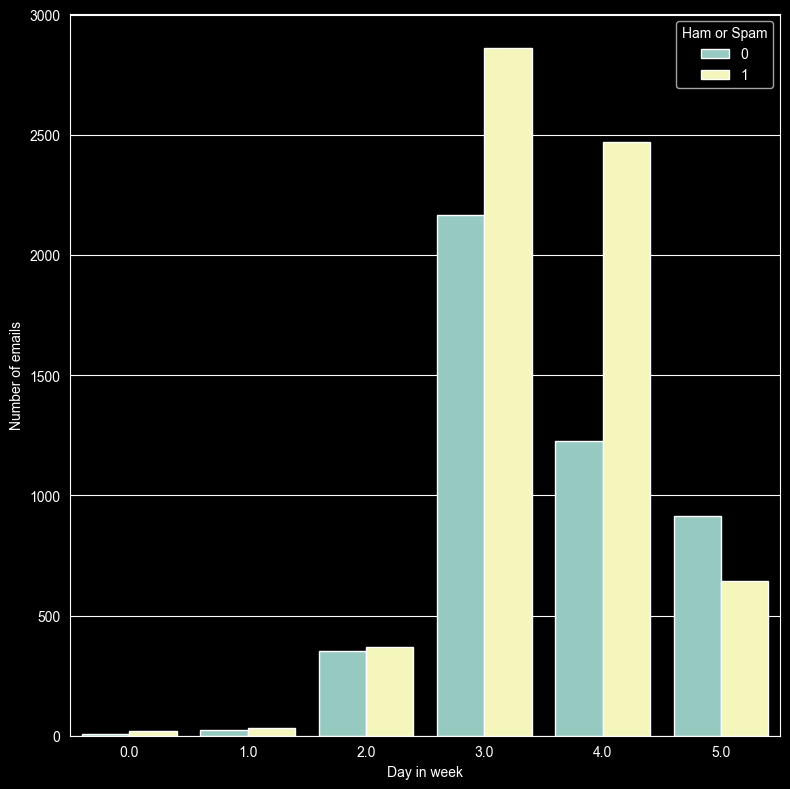

In [18]:
plt.figure(figsize=(8,8))
sb.countplot(data=data,x='day_of_week',hue='label')
plt.xlabel('Day in week')
plt.ylabel('Number of emails')
plt.legend(title='Ham or Spam')
plt.tight_layout()
plt.show()

Nisam siguran na osnovu grafikona da procenim da li se raspodele razlikuju, pa cu primeniti Hi-kvadrat test da utvrdim koliko je jaka veza izmedju dva kategoricka obelezja

In [19]:
from scipy.stats import chi2_contingency
crosstab = pd.crosstab(data['day_of_week'],data['label'])
stat,p,dof,expected = chi2_contingency(crosstab)
print("Ho: Promenljive dan u nedelji i label su statisticki nezavisni")
print("H1: Promenljive dan u nedelji i label su statisticki zavisni")
print(f"P vrednost Hi-kvadrat testa je: {p}")

Ho: Promenljive dan u nedelji i label su statisticki nezavisni
H1: Promenljive dan u nedelji i label su statisticki zavisni
P vrednost Hi-kvadrat testa je: 9.481312932643401e-66


Dobijena p vrednost je manja od 0.05 tako da odbacujem nultu i prihvatam alternativnu hipotezu da postoji zavisnost izmedju ove dve promenljive. Zadrzacu ovu promenljivu


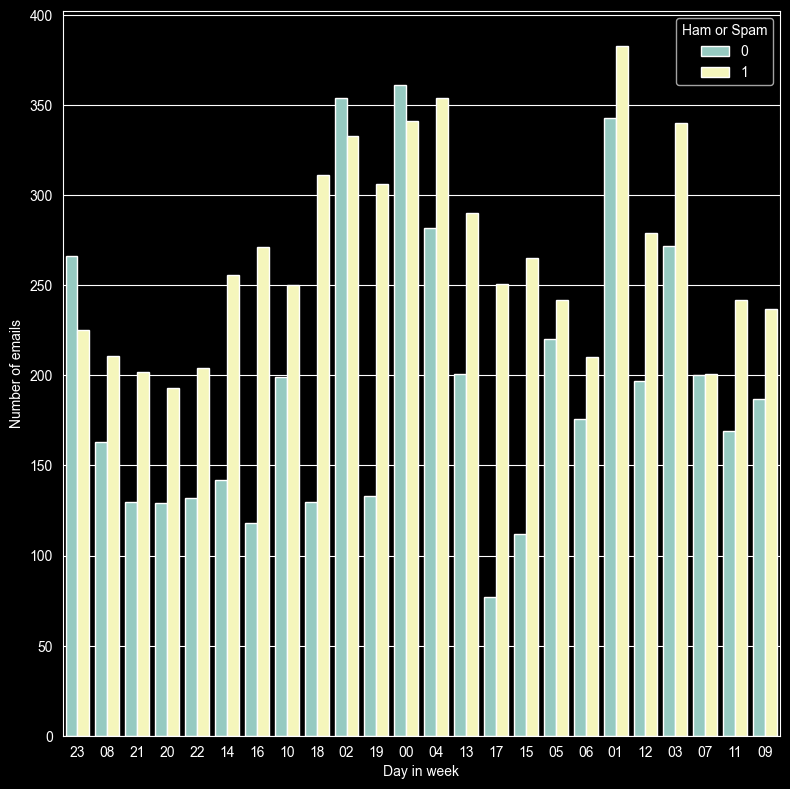

In [20]:
plt.figure(figsize=(8,8))
sb.countplot(data=data,x='hour_of_day',hue='label')
plt.xlabel('Day in week')
plt.ylabel('Number of emails')
plt.legend(title='Ham or Spam')
plt.tight_layout()
plt.show()

Sa grafikona vec mogu da vidim da se raspodele casova u odnosu na labelu raziliku. Ali za svaki slucaj cu primeniti Hi kvadrat test da ovo potvrdim


In [21]:
crosstab = pd.crosstab(data['hour_of_day'],data['label'])
stat,p,dof,expected = chi2_contingency(crosstab)
print("Ho: Promenljive dan u nedelji i label su statisticki nezavisni")
print("H1: Promenljive dan u nedelji i label su statisticki zavisni")
print(f"P vrednost Hi-kvadrat testa je: {p}")

Ho: Promenljive dan u nedelji i label su statisticki nezavisni
H1: Promenljive dan u nedelji i label su statisticki zavisni
P vrednost Hi-kvadrat testa je: 3.853855045534494e-43


Dobijena p vrednost je manja od 0.05 tako da odbacujem nultu i prihvatam alternativnu hipotezu da postoji zavisnost izmedju ove dve promenljive. Zadrzacu ovu promenljivu


Pre nastavka analize potrebno je da proverim kako raspodela promenljive urls u odnosu na vrednost label(phising ili ne) utice na razdvajanje klasa


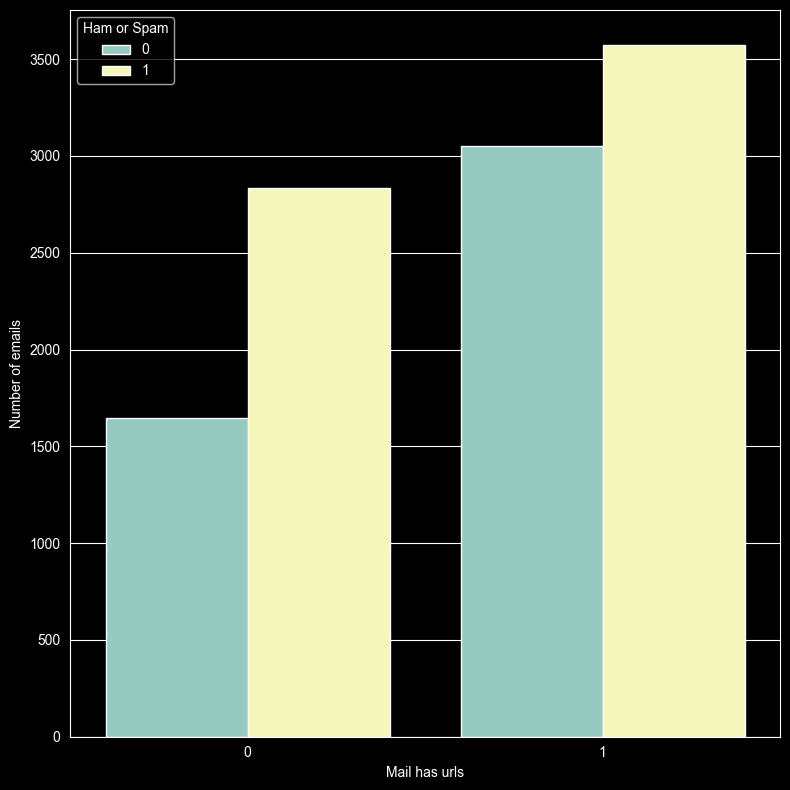

In [22]:
plt.figure(figsize=(8,8))
sb.countplot(data=data, x='urls',hue='label')
plt.xlabel('Mail has urls')
plt.ylabel('Number of emails')
plt.legend(title='Ham or Spam')
plt.tight_layout()
plt.show()

Na osnovu grafikona se moze zakljuciti da su raspodele promenljive urls u odnosu na promenljivu label iste, ovu promenljivu cu odstraniti iz prediktivnih promenljivi

Na osnovu deteljnog pregleda dataset-a može se primetiti veliki broj reply mejlova koji su u formatu Re: (odgovor). Takođe postoji veliki broj mejlova koji u naslovu sadrže neku vrstu zaglavlja tipa [Perl Jobs], ova obeležja zajedno sa forward formatom predstavljaju snažan indikator da ovi mejlovi nisu spam. Koristiću regex-e da izvučem ovo obeležje

In [23]:
import re

are_replies = data[data['subject'].str.match(r"^Re\s*",flags=re.IGNORECASE,na=False)]
ham_replies = are_replies.loc[are_replies['label'] == 0]
print(f"{len(ham_replies)} od {len(are_replies)} mejlova koji sadrze Re: (kao reply) zaista nisu spam mejlovi")

are_forwards = data[data['subject'].str.contains(r"Fwd?\s*",flags=re.IGNORECASE,na = False)]
ham_are_forwards = are_forwards.loc[are_forwards['label']==0]
print(f"{len(ham_are_forwards)} od {len(are_forwards)} mejlova koji sadrze Re: (kao reply) zaista nisu spam mejlovi")

subject_metadata = data[data['subject'].str.contains(r"\[.*?\]",na=False)]
ham_subject_metadata = subject_metadata.loc[subject_metadata['label'] == 0]
print(f"{len(ham_subject_metadata)} od {len(subject_metadata)} mejlova koji sadrze meta podatke u formatu [*] zaista nisu spam mejlovi")

1439 od 1622 mejlova koji sadrze Re: (kao reply) zaista nisu spam mejlovi
102 od 143 mejlova koji sadrze Re: (kao reply) zaista nisu spam mejlovi
2845 od 2855 mejlova koji sadrze meta podatke u formatu [*] zaista nisu spam mejlovi


In [24]:
data['is_reply'] = data['subject'].str.match(r"^Re\s*",flags=re.IGNORECASE,na=False).astype(int)
data['has_subject_header'] = data['subject'].str.contains(r"\[.*?\]",na=False).astype(int)
data['is_forward'] = data['subject'].str.contains(r"Fwd\s*",flags=re.IGNORECASE,na=False).astype(int)

In [25]:
data[['subject','is_reply','has_subject_header','is_forward','label']].sample(10)

,subject,is_reply,has_subject_header,is_forward,label
25192,From Laurie Mackey,0,0,0,1
12146,The most advanced PE pill available today,0,0,0,1
106,The search for high quality m_edz and save you...,0,0,0,1
36176,Re: [Python-Dev] Another GSoC Student Introduc...,1,1,0,0
952,[opensuse] Unable to download list of online r...,0,1,0,0
16590,Re: svn commit: r586641 - /spamassassin/trunk/...,1,0,0,0
10765,Greater length for your masculinity,0,0,0,1
34754,porno Shocking for c5a499fe8a55aa73225c7e6bd47...,0,0,0,1
10393,[opensuse] Refresh Sources Question,0,1,0,0
30105,Pbl.spamhaus.org down?,0,0,0,0


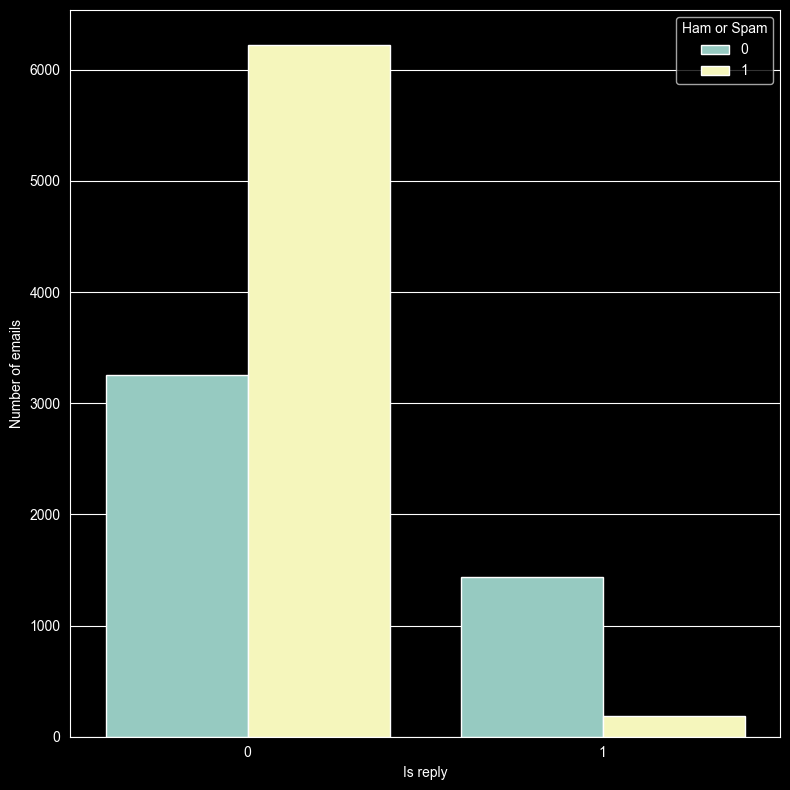

In [26]:
plt.figure(figsize=(8,8))
sb.countplot(data=data, x='is_reply',hue='label')
plt.xlabel('Is reply')
plt.ylabel('Number of emails')
plt.legend(title='Ham or Spam')
plt.tight_layout()
plt.show()

Raspodele promenljive is_reply u odnosu na vrednost labele se razlikuju, zbog toga može doprineti razdvajanju klasa. Zadržaću je u analizi


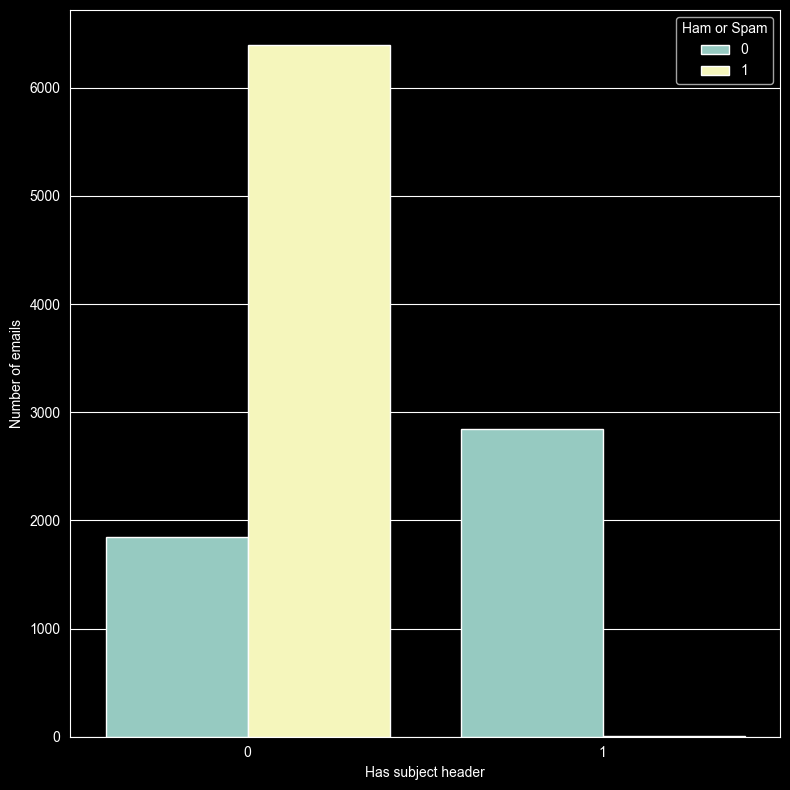

In [27]:
plt.figure(figsize=(8,8))
sb.countplot(data=data, x='has_subject_header',hue='label')
plt.xlabel('Has subject header')
plt.ylabel('Number of emails')
plt.legend(title='Ham or Spam')
plt.tight_layout()
plt.show()

Raspodela promenljive has_subject_header u odnosu na vrednosti zavisne promenljive se značajno razlikuju, promenljiva može doprineti razdvajanju klasa. Zadržaću je u analizi.

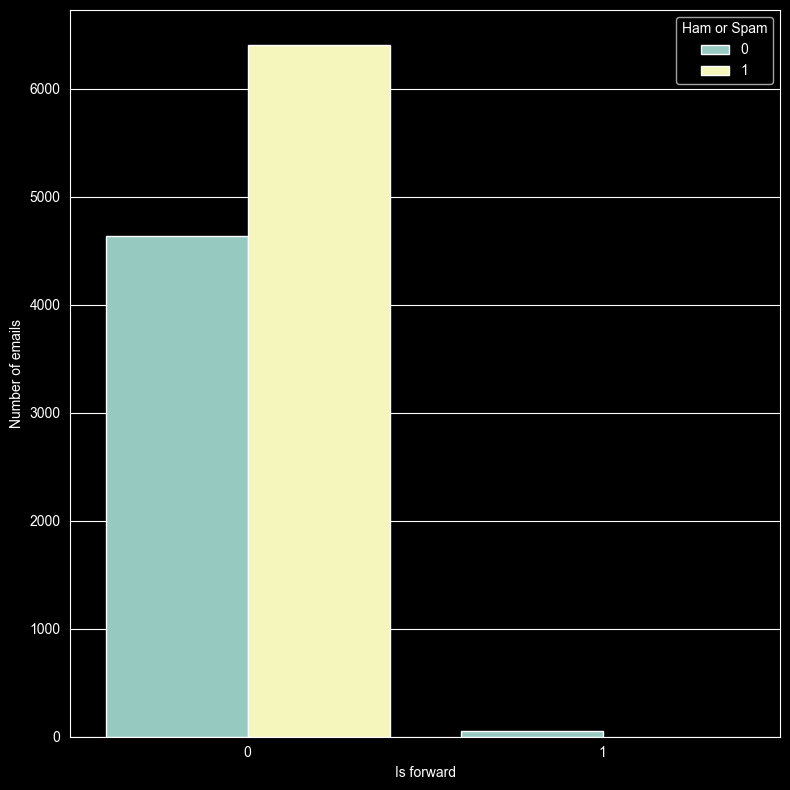

In [28]:
plt.figure(figsize=(8,8))
sb.countplot(data=data, x='is_forward',hue='label')
plt.xlabel('Is forward')
plt.ylabel('Number of emails')
plt.legend(title='Ham or Spam')
plt.tight_layout()
plt.show()

Raspodela promenljive is_forward u odnosu na vrednosti zavisne promenljive se značajno razlikuju, promenljiva može doprineti razdvajanju klasa. Zadržaću je u analizi.


Izdvajanje obeležja - Sender

Promenljiva sender ima sledeci oblik NazivPosiljaoca <emailadresa>. Naziv posiljaoca mi nije od velikog znacaja kao ni korisnicko ime, jedino sto ce mi omoguciti da utvrdim da li je spam mejl ili ne je domen mejl servera.

Sender - provericu da li mejl server u sebi sadrzi brojeve(npr. m1crosoft.com), jer to cesto moze predstavljati kljucan indikator spam mejlova. Opet sama adresa posiljaoca nece imati koristi za treniranje modela, ali moguce je izvesti promenljivu na primer has_number_in_sender_server.

In [29]:
def sender_to_email(sender):
    if sender and "<" in sender:
        email = sender.split("<")[1].removesuffix(">")
        return email
    else:
        return ""
data['sender'] = data['sender'].apply(sender_to_email)

In [30]:
def email_to_domain(email):
    if "@" in email:
        domain = email.split("@")[1]
        return domain
    else:
        return ""
data['sender'] = data['sender'].apply(email_to_domain)

Takođe veliki broj spam mejlova u svom domenu sadrži brojeve, klasičan primer pokušaja obmane su mejlovi koji zamenjuju karaktere brojevima, npr. m1crosoft.com

In [31]:
def domain_has_numbers(email):
    if "@" in email:
        email = email.split("@")[1].removesuffix(">")
        return any(char.isdigit() for char in email)
    return False
data['has_number_in_sender_server'] = data['sender'].apply(domain_has_numbers)

In [32]:
data.loc[(data['has_number_in_sender_server'] == True) & (data['label'] == 1)]

,sender,receiver,subject,body,label,urls,is_internal,day_of_week,hour_of_day,is_reply,has_subject_header,is_forward,has_number_in_sender_server


Ovaj dataset izgleda ne poseduje ni jedan mejl koji sadrži domen ovog tipa, promenljiva će ipak biti preskočena

In [33]:
data.drop(labels=['has_number_in_sender_server'],axis=1,inplace=True)

Takođe testiraće se broj poddomena imejl adrese, obično profesionalni mejlovi imaju kratke domene

In [34]:
def num_of_dots(domain):
    return domain.count('.')
data['email_dots'] = data['sender'].apply(num_of_dots)

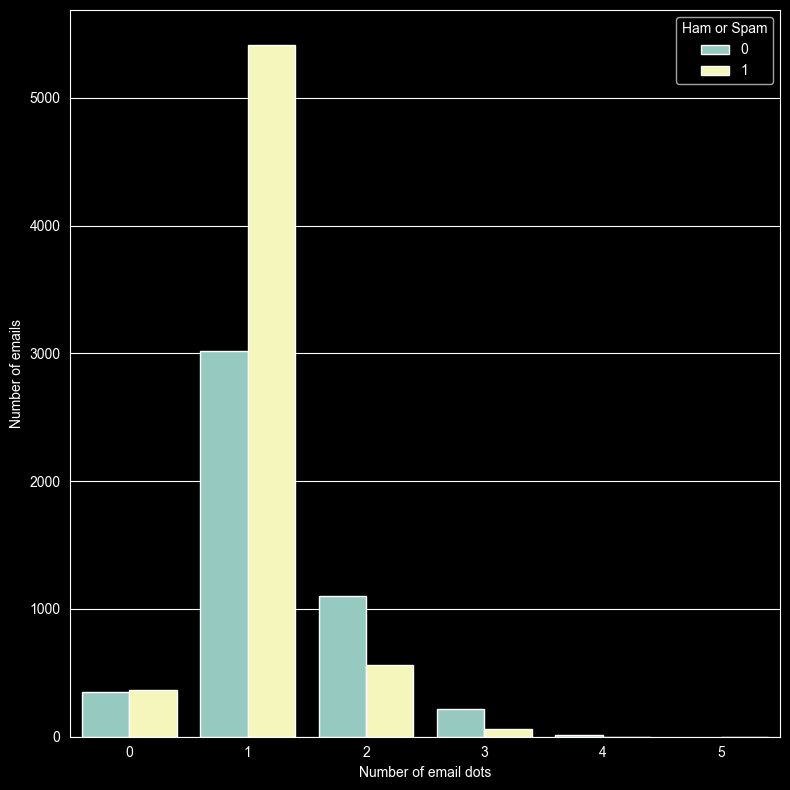

In [35]:
plt.figure(figsize=(8,8))
sb.countplot(data=data, x='email_dots',hue='label')
plt.xlabel('Number of email dots')
plt.ylabel('Number of emails')
plt.legend(title='Ham or Spam')
plt.tight_layout()
plt.show()

Na osnovu grafikona se moze zaključiti da ova promenljiva ne doprinosi dovoljno razdvajanju klasa, ova promenljiva nee biti razmatrana u analizi

Na kraju ću još proveriti značajnost promenljive url u razdvajanju klasa

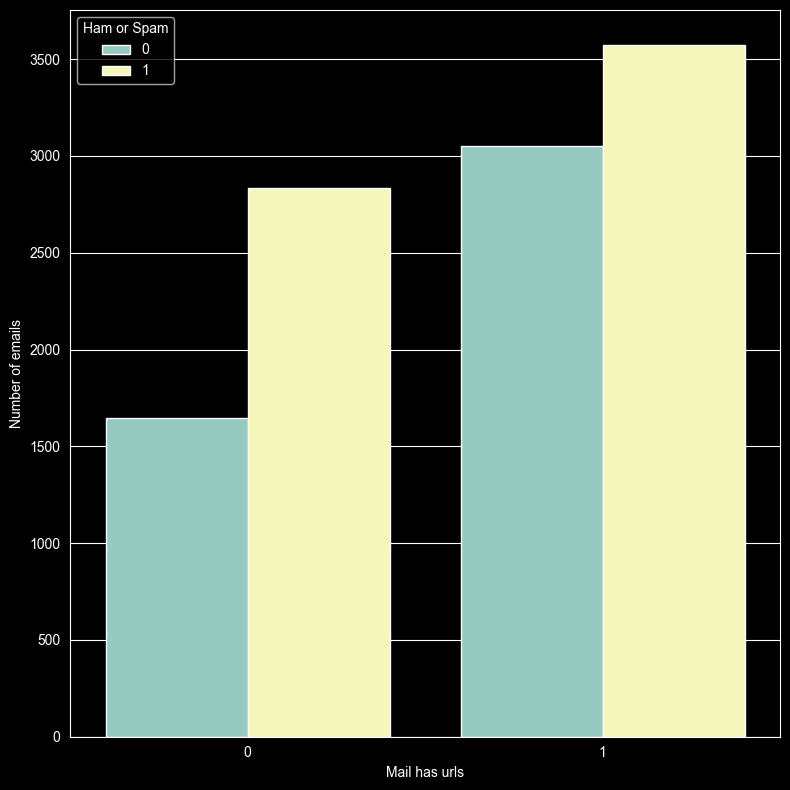

In [36]:
plt.figure(figsize=(8,8))
sb.countplot(data=data, x='urls',hue='label')
plt.xlabel('Mail has urls')
plt.ylabel('Number of emails')
plt.legend(title='Ham or Spam')
plt.tight_layout()
plt.show()

Iz sender promenljive su izvucena znacanja obelezja za analizu, tako da cu je sad odstraniti posto nema svrhu u daljem treniranju

In [37]:
data.drop(labels=['sender'],axis=1,inplace=True)

In [38]:
data.label.value_counts(normalize=True)

label
1    0.577283
0    0.422717
Name: proportion, dtype: float64

Sobzirom da ne postoji veliki disbalans u izlaznoj promenljivoj, neću koristiti SMOTE metodu balansiranja


Sledece sto je potrebno da uradim je ciscenje tekstualnih podataka od nepotrebih karaktera.


In [39]:
import re
def clean_text(text):
    if not isinstance(text,str):
        return ""

    try:
        # Čišćenje poruka koje su vezane za MIME format
        text = re.sub(r'^(content-type|x-mailer|x-priority|mime-version|content-transfer-encoding|return-path|delivered-to):.*$', '', text, flags=re.MULTILINE)

        # Zamena url i email adresa
        text = re.sub(r'http\S+|www\.\S+', ' ', text)
        text = re.sub(r'\S+@\S+', ' ', text)

        # Zamena Reply i Forward simbola, sobzirom da ne želim da model bude treniran da asocira reply sa bezbednim mejlom,
        # za to već posedujem obeležje is_reply
        text = re.sub(r"(re|fwd?):?\s*","",text,flags=re.IGNORECASE)
        text = re.sub(r"\[.*?\]","",text)

        # Uklanjanje html tagova
        text = re.sub(r"<[^>]+>","",text)

        text = re.sub(r"[^a-zA-Z0-9'\s]"," ",text)
        # Zamena više od jednog white-space-a
        return re.sub(r"\s+"," ",text).strip()

    except Exception as e:
        return f"Error {e} \n on text: {text}"

data['subject'] = data['subject'].apply(clean_text)
data['body'] = data['body'].apply(clean_text)

In [40]:
data[['subject','body']]

,subject,body
0,Never age to be a loser,Buck up your troubles caused by small dimensio...
1,Befriend Jenna Jameson,Upgrade your sex and pleasus with these techni...
2,CNN com Daily Top 10,THE DAILY TOP 10 from CNN com Top videos and s...
3,svn commit r619753 in spamassassin trunk lib M...,Would anyone object to moving so from this lis...
4,SpecialPricesPharmMoinfo,WelcomeFastShippingCustomerSupport
...,...,...
39136,Finally your new healthy life 85,Find your love stick gain heCLICK HEURl qOqZCJ...
39138,I want to cancel my account,How do I cancel my account I want to erase it ...
39139,some contact information for you,This message is intended for SAVE SAVE SAVE ON...
39143,Woman 38 Richter,Lana I am a 25 year old woman Seeking seeking ...


Sobzirom da SBERT embeduje rečenice u vektore potrebno je da se očuva semantičko značenje tih rečenica, tako da neću raditi lematizaciju koja bi narušila njihov kontekst

In [41]:
data[['subject','body']]

,subject,body
0,Never age to be a loser,Buck up your troubles caused by small dimensio...
1,Befriend Jenna Jameson,Upgrade your sex and pleasus with these techni...
2,CNN com Daily Top 10,THE DAILY TOP 10 from CNN com Top videos and s...
3,svn commit r619753 in spamassassin trunk lib M...,Would anyone object to moving so from this lis...
4,SpecialPricesPharmMoinfo,WelcomeFastShippingCustomerSupport
...,...,...
39136,Finally your new healthy life 85,Find your love stick gain heCLICK HEURl qOqZCJ...
39138,I want to cancel my account,How do I cancel my account I want to erase it ...
39139,some contact information for you,This message is intended for SAVE SAVE SAVE ON...
39143,Woman 38 Richter,Lana I am a 25 year old woman Seeking seeking ...


Provera NA vrednosti nakon obrade promenljivih

In [42]:
data.isna().sum()

receiver               0
subject                0
body                   0
label                  0
urls                   0
is_internal            0
day_of_week           12
hour_of_day           12
is_reply               0
has_subject_header     0
is_forward             0
email_dots             0
dtype: int64

Sobzirom da mali broj opservacija sadrži NA vrednosti (<10%), odlučio sam da ih odstranim iz dataset-a


In [43]:
empty_subjects_indices = data[data['subject'] == ""].index
data.drop(empty_subjects_indices, inplace=True)

empty_body_indices = data[data['body'] == ""].index
data.drop(empty_body_indices,inplace=True)

missing_days = data[data.isna()['day_of_week'] == True].index
data.drop(missing_days,inplace=True)

missing_hours = data[data.isna()['hour_of_day'] == True].index
data.drop(missing_hours,inplace=True)

Finalne ulazne promenljive predstavljaju kombinaciju obradjenih tekstualnih promenljivi i izdvojenih obeležja


Train test podela mejlova, gde 20% pripada test skupu

In [44]:
from sklearn.model_selection import train_test_split
feature_cols = ['day_of_week', 'hour_of_day', 'is_forward','has_subject_header','is_reply','is_internal']

y_encodings,y_levels = pd.factorize(data['label'])
X_train_raw, X_test_raw, y_train,y_test = train_test_split(
    data, data['label'],test_size=0.2,random_state=42,stratify=y_encodings
)

In [45]:
!pip install -U sentence-transformers
from sentence_transformers import SentenceTransformer

sbert_model = SentenceTransformer("all-MiniLM-L6-v2")

E:\NLPPhisingDetection\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1161.90it/s, Materializing param=pooler.dense.weight]                             
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Prvo ću izvršiti embedovanje rečenica naslova i tela mejla a zatim ih spojiti u jedan dataframe zajedno sa izvedenim obeležjima

In [46]:
import numpy as np
X_train_sbert_subject = sbert_model.encode(X_train_raw['subject'].tolist(),show_progress_bar=True)
X_train_sbert_body = sbert_model.encode(X_train_raw['body'].tolist(),show_progress_bar=True)

X_test_sbert_subject = sbert_model.encode(X_test_raw['subject'].tolist(),show_progress_bar=True)
X_test_sbert_body = sbert_model.encode(X_test_raw['body'].tolist(),show_progress_bar=True)

X_train_final = np.hstack((X_train_sbert_subject,X_train_sbert_body,X_train_raw[feature_cols].values))

X_test_final = np.hstack((X_test_sbert_subject,X_test_sbert_body,X_test_raw[feature_cols].values))


Batches: 100%|██████████| 69/69 [00:16<00:00,  4.21it/s]


Kreiranje pipeline za logisticku regresiju. Posto su promenljive različitih opsega potrebno je propustiti model kroz Scaler. Skale vektora nisu iste sa skalama izvedenih obeležja

In [47]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

pipe_1 = Pipeline([
    ('scaler',StandardScaler()),
    ('classifier',LogisticRegression(max_iter=1000,solver='liblinear'))
])

pipe_1.fit(X_train_final,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may n

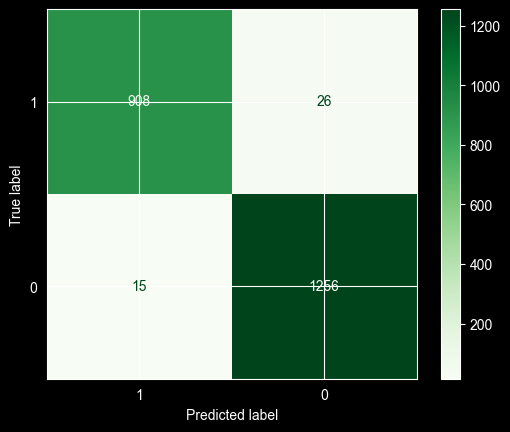

In [48]:
from sklearn.metrics import ConfusionMatrixDisplay,classification_report
ConfusionMatrixDisplay.from_estimator(pipe_1, X_test_final, y_test, display_labels=y_levels, cmap='Greens');

908 mejlova je predviđeno kao ne spam od 934 spam mejla, dok je 15 predviđeno kao spam, a zapravo nisu

1256 mejlova je predviđeno kao ne spam od 1271 ne spam mejla, dok je 26 predviđeno kao ne spam, a zapravo jesu

In [49]:
prediction_1 = pipe_1.predict(X_test_final)
report_1 = classification_report(y_true = y_test, y_pred = prediction_1)
print(report_1)

              precision    recall  f1-score   support

           0       0.98      0.97      0.98       934
           1       0.98      0.99      0.98      1271

    accuracy                           0.98      2205
   macro avg       0.98      0.98      0.98      2205
weighted avg       0.98      0.98      0.98      2205



Preciznost govori da od svih mejlova, koje je model označio kao spam, 98% su zapravo spam, a od svih mejlova koje je model označio kao ne spam, 98% zapravo nisu spam

Odziv govori da od svih spam mejlova, model je uspeo da prepozna 99% spam mejlova, a od svih ne spam mejlova uspeo je da prepozna 97%

F1 skor je visok tako da se može zaključiti da je model izbalansiran

Pronalaženje optimalnog hiperparametra regularizacije C koji penalizuje eksremne koeficijente modela

In [50]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'classifier__C': [0.001, 0.01, 0.1, 1, 10, 100],
}

grid_search = GridSearchCV(pipe_1, param_grid, cv=5, scoring='f1', n_jobs=-1)
grid_search.fit(X_train_final, y_train)

best_c = grid_search.best_params_['classifier__C']
print(f"Najbolje c: {best_c}")

Najbolje c: 0.1


In [51]:
pipe_1.set_params(
    classifier__C=best_c
)
pipe_1.fit(X_train_final,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.1
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may n

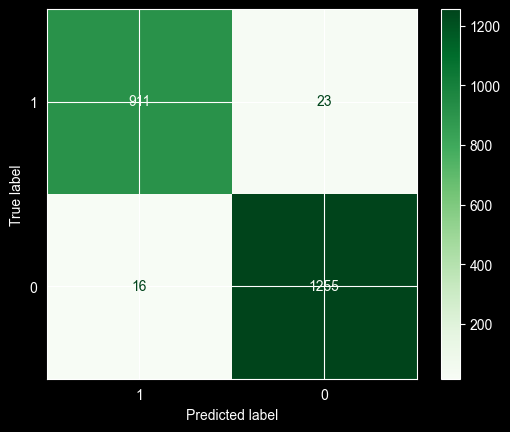

In [52]:
from sklearn.metrics import ConfusionMatrixDisplay,classification_report
ConfusionMatrixDisplay.from_estimator(pipe_1, X_test_final, y_test, display_labels=y_levels, cmap='Greens');

911 mejlova je predviđeno kao spam od 934, dok je 16 predviđeno kao spam, a zapravo nisu

1255 mejlova je predviđeno kao ne spam od 1271 ne spam mejla, dok je 23 predviđeno kao ne spam, a zapravo jesu

In [53]:
prediction_2 = pipe_1.predict(X_test_final)
report_2 = classification_report(y_true = y_test, y_pred = prediction_2)
print(report_2)

              precision    recall  f1-score   support

           0       0.98      0.98      0.98       934
           1       0.98      0.99      0.98      1271

    accuracy                           0.98      2205
   macro avg       0.98      0.98      0.98      2205
weighted avg       0.98      0.98      0.98      2205



Primenom optimalnih hipermodela, odziv modela u prepoznavanju ne spam mejlova je opao za 1%

Eksporotvanje modela za zaključak

In [54]:
import joblib

joblib.dump(pipe_1,'../models/sbert_lr_ceas.pkl')
joblib.dump(X_test_final,'../models/X_test_sbert_lr_ceas.pkl')
joblib.dump(y_test,'../models/y_test_sbert_lr_ceas.pkl')

['../models/y_test_sbert_lr_ceas.pkl']